/var/folders/1j/nn5d0__s1tn209qg1jhvwh8r0000gn/T/ipykernel_58370/1134822183.py:182: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 4))


Generated 25 axial-force plots (one per geometry–motion combination).

=== Engineering Insight (from current scenarios) ===
Highest tensile force in AB:
  Geometry index: 4, Motion index: 4
  L1=2.0, L2=1.0, Mb=1.0, Mc=3.0, w1=6.0, w2=2.0
  Max tension N_max = 336.000

Highest compressive force in AB:
  Geometry index: 1, Motion index: 1
  L1=1.0, L2=1.0, Mb=1.0, Mc=1.0, w1=2.0, w2=1.0
  Max compression N_min = 7.000

Qualitative driver of extreme loads: larger angular speeds (especially w1), larger distal mass Mc, and longer links increase centripetal accelerations and thus axial forces in AB.


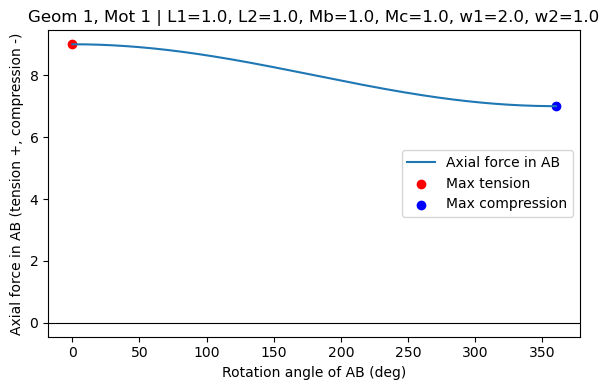

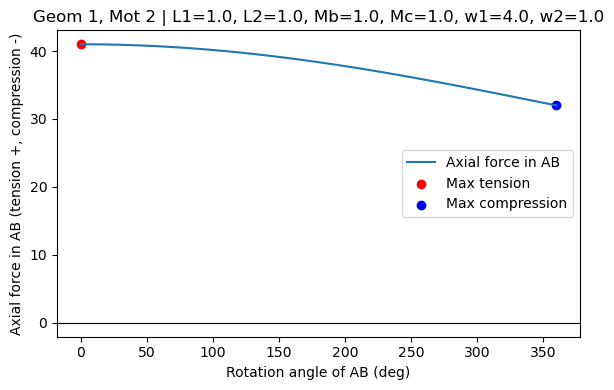

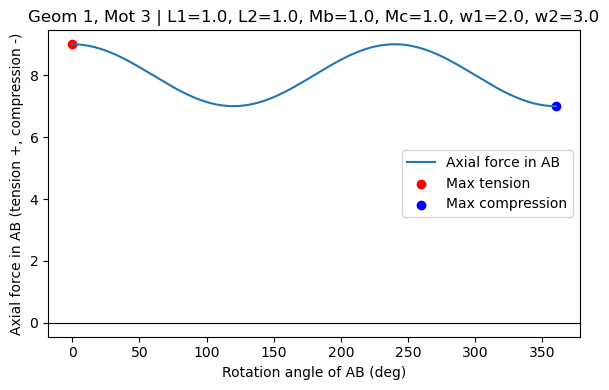

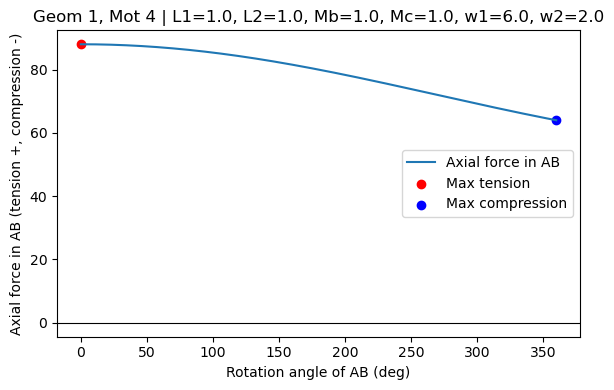

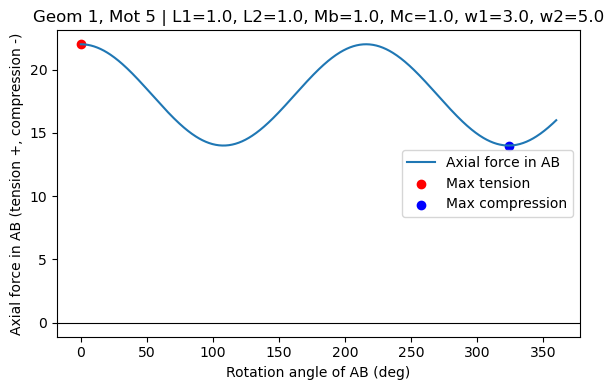

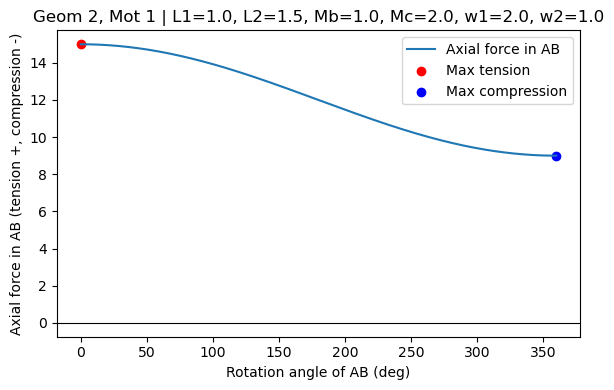

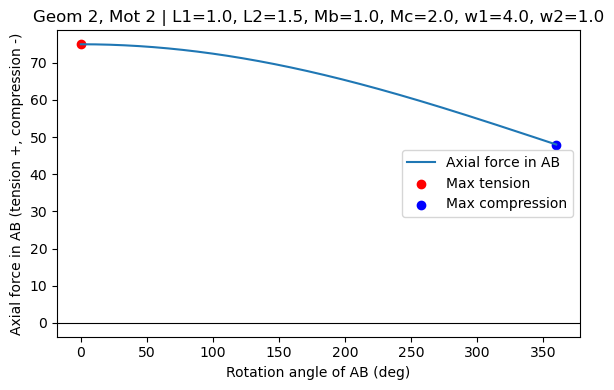

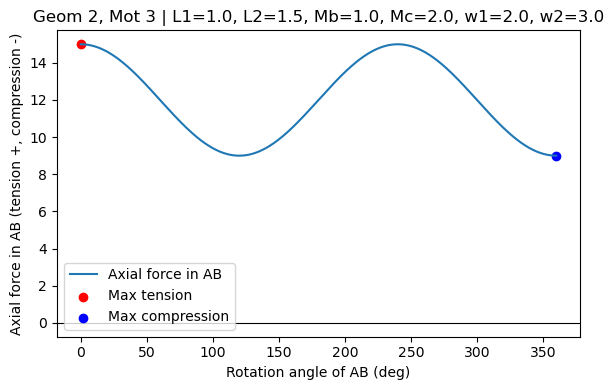

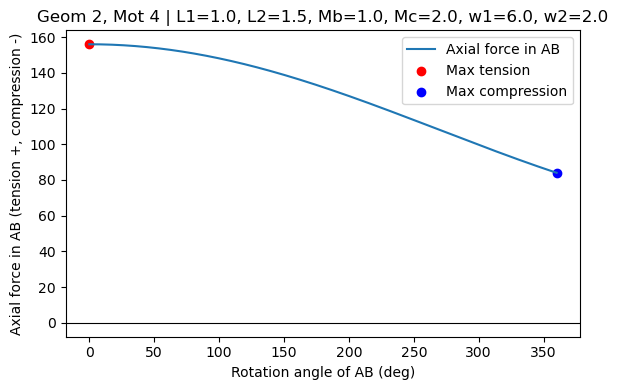

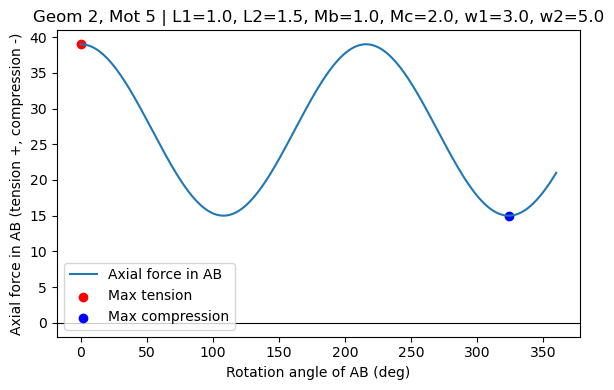

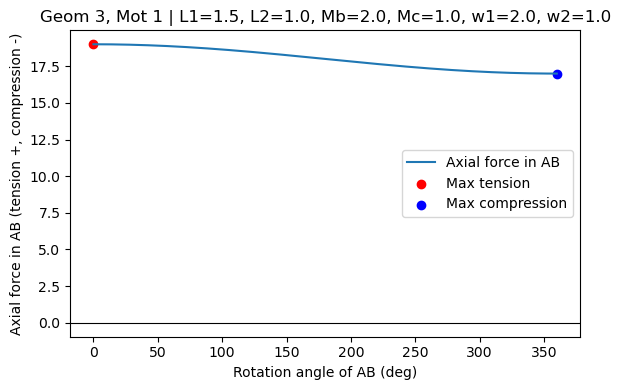

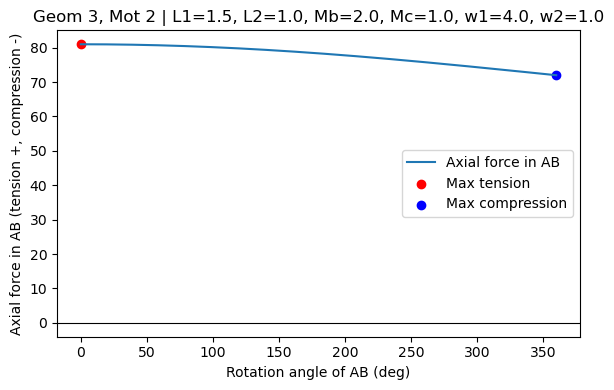

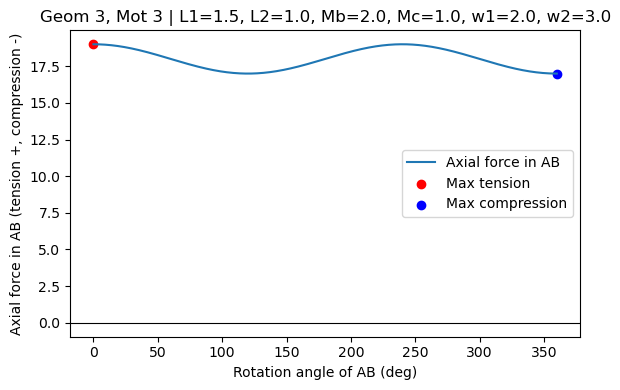

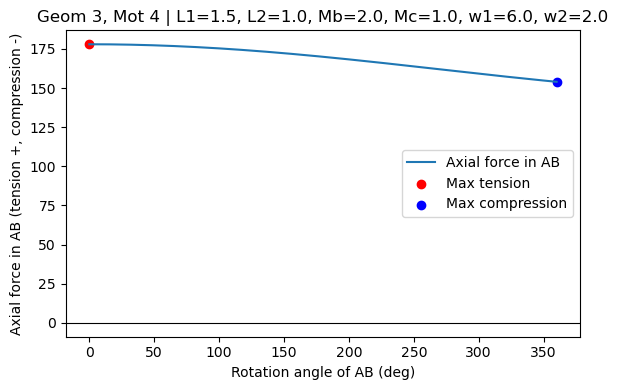

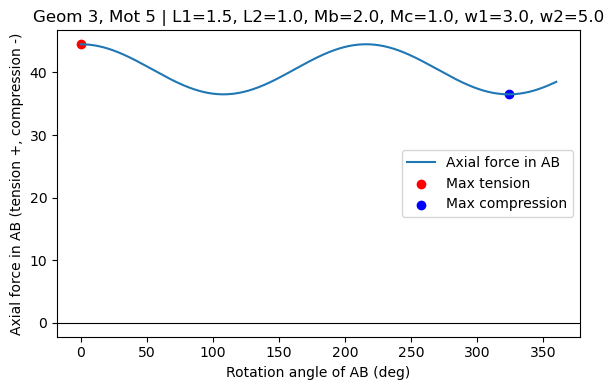

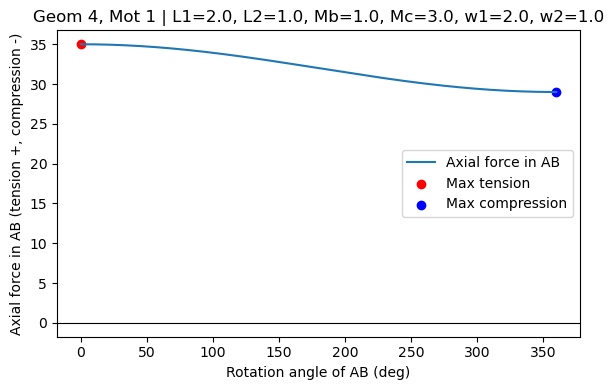

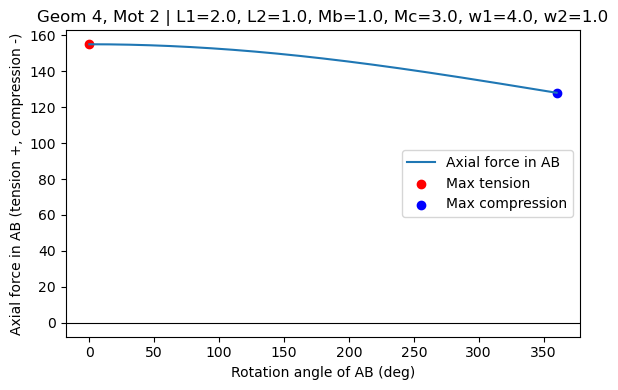

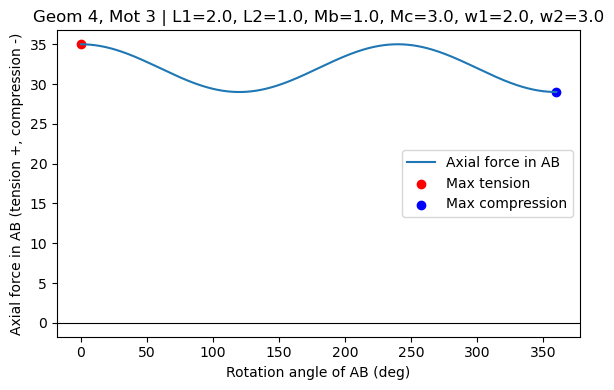

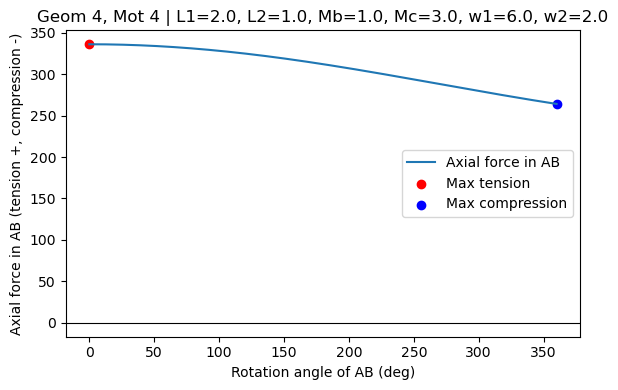

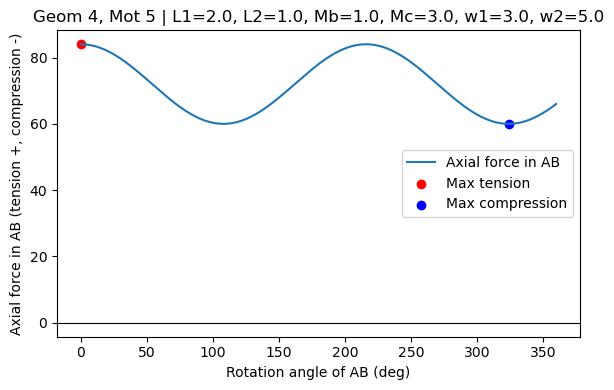

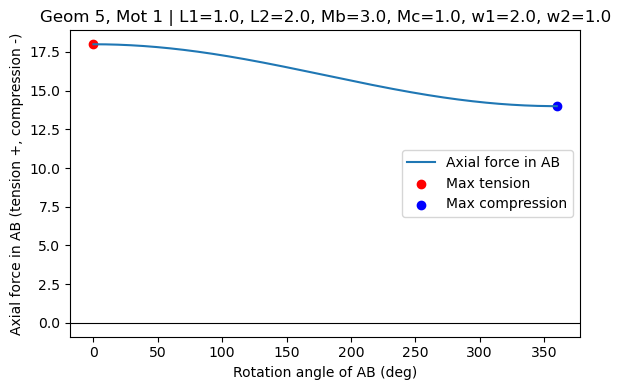

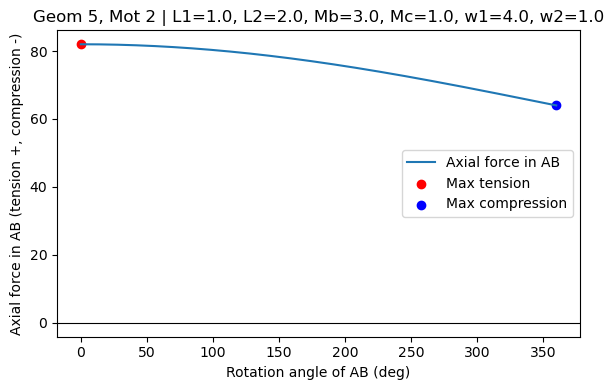

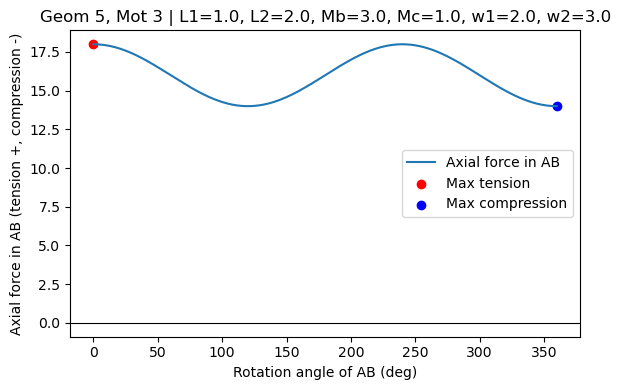

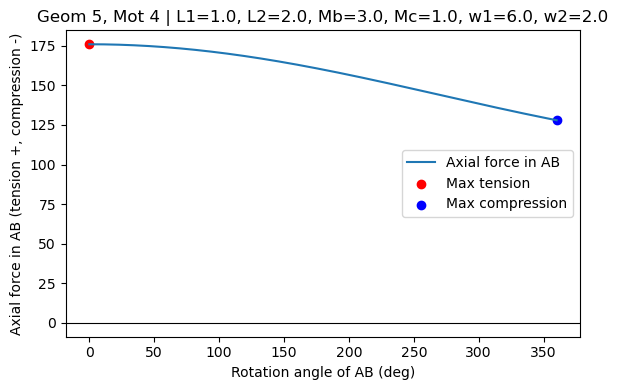

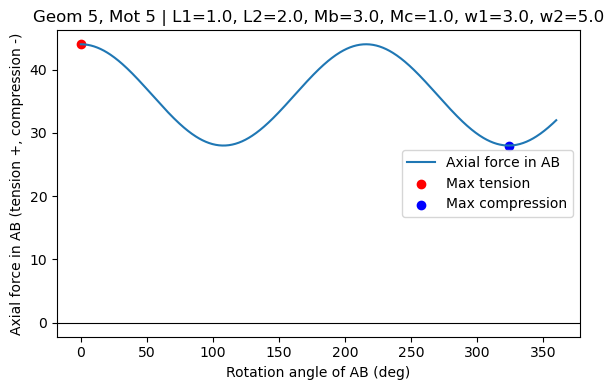

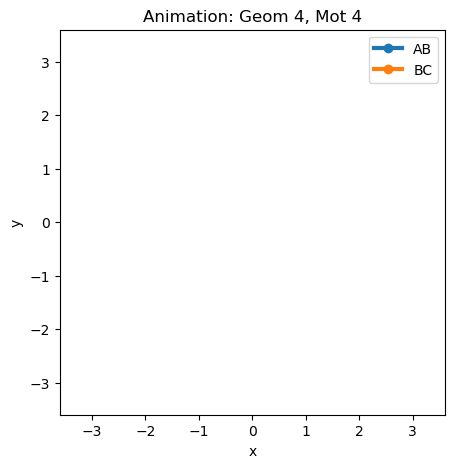

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ============================================================
# One-page modeling explanation (short, but complete)
# ============================================================
"""
Modeling approach (planar two-link, prescribed motion)

1. Geometry and coordinates
   - A is fixed at the origin.
   - Link AB has length L1, link BC has length L2.
   - Zero angle is defined vertically upward (along +y).
   - Angle of AB: θ(t) = ω1 * t, measured from +y, positive counterclockwise.
   - Link BC rotates clockwise relative to B with constant angular velocity ω2.
     Its absolute angle from +y is θ_BC(t) = θ(t) - ω2 * t.
   - Positions:
       B: r_B = [L1 * sin(θ), L1 * cos(θ)]
       C: r_C = r_B + [L2 * sin(θ_BC), L2 * cos(θ_BC)]

2. Velocities and accelerations (constant angular velocities)
   - θ̇ = ω1, θ̈ = 0
   - θ̇_BC = ω1 - ω2, θ̈_BC = 0
   - For a point at distance L with angle α from +y:
       r = [L sin α, L cos α]
       v = L α̇ [cos α, -sin α]
       a = L α̇² [-sin α, -cos α]  (pure centripetal, since α̈ = 0)
   - Therefore:
       a_B = L1 * ω1² * [-sin θ, -cos θ]
       a_C = a_B + L2 * (ω1 - ω2)² * [-sin θ_BC, -cos θ_BC]

3. Dynamics and axial force in AB
   - Lumped masses: M_b at B, M_c at C.
   - Links are massless; only joint forces transmit between masses.
   - Unknown joint forces:
       F_AB: force on mass at B from link AB
       F_BC_on_B: force on B from link BC
       F_BC_on_C: force on C from link BC (equal and opposite to F_BC_on_B)
   - Equations of motion:
       For mass at C:  F_BC_on_C = M_c * a_C  ⇒  F_BC_on_B = -M_c * a_C
       For mass at B:  F_AB + F_BC_on_B = M_b * a_B
                      ⇒ F_AB - M_c * a_C = M_b * a_B
                      ⇒ F_AB = M_b * a_B + M_c * a_C
   - Axial force in AB is the component of F_AB along the link AB.
     Let e_AB be the unit vector from A to B:
       e_AB = r_B / |r_B|
     The scalar axial force N is defined tension-positive:
       - If N > 0: AB is in tension (pulling the joints together).
       - If N < 0: AB is in compression (pushing the joints apart).
     Force on B from AB is F_AB. Tension means F_AB points from B toward A,
     i.e., opposite to e_AB. Therefore:
       N = - F_AB · e_AB

4. Simulation and outputs
   - For each geometry–motion combination:
       * Simulate θ from 0 to 360° (one full rotation of AB).
       * Compute r_B, r_C, a_B, a_C, F_AB, and axial force N(θ).
       * Plot N vs θ (degrees) with clear labels.
       * Highlight maximum tension and maximum compression points.
   - A simple animation shows the motion of A–B–C for one selected combination.
"""

# ============================================================
# User-configurable input data
# ============================================================

# Geometry scenarios: list of dicts
# Each: length AB (L1), length BC (L2), mass at B (Mb), mass at C (Mc)
geometry_scenarios = [
    {"L1": 1.0, "L2": 1.0, "Mb": 1.0, "Mc": 1.0},
    {"L1": 1.0, "L2": 1.5, "Mb": 1.0, "Mc": 2.0},
    {"L1": 1.5, "L2": 1.0, "Mb": 2.0, "Mc": 1.0},
    {"L1": 2.0, "L2": 1.0, "Mb": 1.0, "Mc": 3.0},
    {"L1": 1.0, "L2": 2.0, "Mb": 3.0, "Mc": 1.0},
]

# Motion scenarios: list of dicts
# Each: angular velocity of AB (ω1, rad/s), angular velocity of BC relative to B (ω2, rad/s, clockwise)
# Note: ω1 is CCW, ω2 is CW relative, so BC absolute angle rate is (ω1 - ω2).
motion_scenarios = [
    {"w1": 2.0, "w2": 1.0},
    {"w1": 4.0, "w2": 1.0},
    {"w1": 2.0, "w2": 3.0},
    {"w1": 6.0, "w2": 2.0},
    {"w1": 3.0, "w2": 5.0},
]

# Number of angle samples per revolution
n_steps = 720  # finer resolution for smooth plots

# ============================================================
# Core kinematics and dynamics functions
# ============================================================

def compute_kinematics_and_axial_force(L1, L2, Mb, Mc, w1, w2, n_steps=720):
    """
    Compute θ, axial force N(θ), and some kinematic data for one combination.
    Returns:
        theta_deg: array of AB angles in degrees [0, 360]
        N: axial force in AB (tension positive, compression negative)
        rB, rC: positions of B and C (for possible post-processing)
    """
    # Angle of AB from +y, 0..2π
    theta = np.linspace(0.0, 2.0 * np.pi, n_steps)
    theta_deg = np.degrees(theta)

    # Angles
    theta_B = theta                      # AB angle
    theta_BC = theta - w2 / w1 * theta   # since t = θ / ω1, θ_BC = θ - ω2 t = θ - (ω2/ω1) θ

    # But better: compute time explicitly to avoid confusion
    t = theta / w1                       # t = θ / ω1
    theta_B = w1 * t                     # = θ
    theta_BC = theta_B - w2 * t          # absolute angle of BC from +y

    # Positions
    xB = L1 * np.sin(theta_B)
    yB = L1 * np.cos(theta_B)
    xC = xB + L2 * np.sin(theta_BC)
    yC = yB + L2 * np.cos(theta_BC)

    rB = np.vstack((xB, yB))  # shape (2, n)
    rC = np.vstack((xC, yC))

    # Accelerations (pure centripetal, since angular accelerations are zero)
    aB = L1 * (w1 ** 2) * np.vstack((-np.sin(theta_B), -np.cos(theta_B)))
    w_rel = (w1 - w2)
    a_rel_C = L2 * (w_rel ** 2) * np.vstack((-np.sin(theta_BC), -np.cos(theta_BC)))
    aC = aB + a_rel_C

    # Joint force at B from AB: F_AB = Mb * aB + Mc * aC
    F_AB = Mb * aB + Mc * aC  # shape (2, n)

    # Unit vector along AB from A to B
    AB_len = np.sqrt(xB**2 + yB**2)
    eAB = np.vstack((xB / AB_len, yB / AB_len))

    # Axial force in AB (tension positive)
    # Tension means F_AB on B points from B to A = -eAB, so:
    # N = - F_AB · eAB
    N = -np.sum(F_AB * eAB, axis=0)

    return theta_deg, N, rB, rC


# ============================================================
# Run all combinations and plot axial force vs angle
# ============================================================

all_results = []  # store for later insight

fig_count = 0
for i_g, geom in enumerate(geometry_scenarios):
    for i_m, mot in enumerate(motion_scenarios):
        L1, L2, Mb, Mc = geom["L1"], geom["L2"], geom["Mb"], geom["Mc"]
        w1, w2 = mot["w1"], mot["w2"]

        theta_deg, N, rB, rC = compute_kinematics_and_axial_force(
            L1, L2, Mb, Mc, w1, w2, n_steps=n_steps
        )

        # Store for global insight
        combo_info = {
            "geom_index": i_g,
            "motion_index": i_m,
            "L1": L1,
            "L2": L2,
            "Mb": Mb,
            "Mc": Mc,
            "w1": w1,
            "w2": w2,
            "theta_deg": theta_deg,
            "N": N,
            "N_max": np.max(N),
            "N_min": np.min(N),
        }
        all_results.append(combo_info)

        # Plot for this combination
        fig_count += 1
        plt.figure(figsize=(6, 4))
        plt.plot(theta_deg, N, label="Axial force in AB")

        # Highlight extreme tension and compression
        idx_max = np.argmax(N)
        idx_min = np.argmin(N)
        plt.scatter(theta_deg[idx_max], N[idx_max], color="red", label="Max tension")
        plt.scatter(theta_deg[idx_min], N[idx_min], color="blue", label="Max compression")

        plt.axhline(0, color="k", linewidth=0.8)
        plt.xlabel("Rotation angle of AB (deg)")
        plt.ylabel("Axial force in AB (tension +, compression -)")
        plt.title(
            f"Geom {i_g+1}, Mot {i_m+1} | "
            f"L1={L1}, L2={L2}, Mb={Mb}, Mc={Mc}, w1={w1}, w2={w2}"
        )
        plt.legend()
        plt.tight_layout()

print(f"Generated {fig_count} axial-force plots (one per geometry–motion combination).")

# ============================================================
# Engineering insight: find extreme tension and compression
# ============================================================

# Highest tensile force (max N)
max_tension_combo = max(all_results, key=lambda c: c["N_max"])
# Highest compressive force (most negative N)
max_compression_combo = min(all_results, key=lambda c: c["N_min"])

print("\n=== Engineering Insight (from current scenarios) ===")
print("Highest tensile force in AB:")
print(
    f"  Geometry index: {max_tension_combo['geom_index']+1}, "
    f"Motion index: {max_tension_combo['motion_index']+1}"
)
print(
    f"  L1={max_tension_combo['L1']}, L2={max_tension_combo['L2']}, "
    f"Mb={max_tension_combo['Mb']}, Mc={max_tension_combo['Mc']}, "
    f"w1={max_tension_combo['w1']}, w2={max_tension_combo['w2']}"
)
print(f"  Max tension N_max = {max_tension_combo['N_max']:.3f}")

print("\nHighest compressive force in AB:")
print(
    f"  Geometry index: {max_compression_combo['geom_index']+1}, "
    f"Motion index: {max_compression_combo['motion_index']+1}"
)
print(
    f"  L1={max_compression_combo['L1']}, L2={max_compression_combo['L2']}, "
    f"Mb={max_compression_combo['Mb']}, Mc={max_compression_combo['Mc']}, "
    f"w1={max_compression_combo['w1']}, w2={max_compression_combo['w2']}"
)
print(f"  Max compression N_min = {max_compression_combo['N_min']:.3f}")

print(
    "\nQualitative driver of extreme loads: "
    "larger angular speeds (especially w1), larger distal mass Mc, and longer links "
    "increase centripetal accelerations and thus axial forces in AB."
)

# ============================================================
# Simple movement animation for one selected combination
# ============================================================

# Choose one combination to animate (e.g., the one with highest tension)
anim_combo = max_tension_combo
theta_deg = anim_combo["theta_deg"]
N = anim_combo["N"]
L1 = anim_combo["L1"]
L2 = anim_combo["L2"]
Mb = anim_combo["Mb"]
Mc = anim_combo["Mc"]
w1 = anim_combo["w1"]
w2 = anim_combo["w2"]

# Recompute positions for animation
theta = np.radians(theta_deg)
t = theta / w1
theta_B = w1 * t
theta_BC = theta_B - w2 * t

xB = L1 * np.sin(theta_B)
yB = L1 * np.cos(theta_B)
xC = xB + L2 * np.sin(theta_BC)
yC = yB + L2 * np.cos(theta_BC)

fig_anim, ax_anim = plt.subplots(figsize=(5, 5))
ax_anim.set_aspect("equal", "box")
max_len = L1 + L2
ax_anim.set_xlim(-max_len * 1.2, max_len * 1.2)
ax_anim.set_ylim(-max_len * 1.2, max_len * 1.2)
ax_anim.set_xlabel("x")
ax_anim.set_ylabel("y")
ax_anim.set_title(
    f"Animation: Geom {anim_combo['geom_index']+1}, Mot {anim_combo['motion_index']+1}"
)

line_AB, = ax_anim.plot([], [], "o-", lw=3, label="AB")
line_BC, = ax_anim.plot([], [], "o-", lw=3, label="BC")
text_info = ax_anim.text(
    0.02, 0.95, "", transform=ax_anim.transAxes, va="top", ha="left"
)
ax_anim.legend()

def init():
    line_AB.set_data([], [])
    line_BC.set_data([], [])
    text_info.set_text("")
    return line_AB, line_BC, text_info

def update(frame):
    xA, yA = 0.0, 0.0
    xBf, yBf = xB[frame], yB[frame]
    xCf, yCf = xC[frame], yC[frame]

    line_AB.set_data([xA, xBf], [yA, yBf])
    line_BC.set_data([xBf, xCf], [yBf, yCf])

    text_info.set_text(
        f"θ_AB = {theta_deg[frame]:.1f} deg\n"
        f"N_AB = {N[frame]:.2f} (tension +)"
    )
    return line_AB, line_BC, text_info

ani = FuncAnimation(
    fig_anim, update, frames=len(theta_deg), init_func=init, blit=True, interval=20
)

plt.show()
